# Titanic example

Data downloaded from Kaggle.

__Objetive:__ To predict the survival of titanic passenger

The Dataset is already split into Train and Test subsets.

In [4]:
#Importamos librerías
%pylab inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import plotly.express as px 

Populating the interactive namespace from numpy and matplotlib


In [2]:
#Cragamos el archivo
train_real = pd.read_csv('C:/Users/Vazsa/OneDrive/Escritorio/titanic/titanic/train.csv', index_col=0)
test_real = pd.read_csv('C:/Users/Vazsa/OneDrive/Escritorio/titanic/titanic/test.csv', index_col=0)

In [3]:
train, test, y_train, y_test = train_test_split(train_real, train_real.Survived, stratify=train_real.Survived)

In [5]:
print('Shapes of arrays')
print(train_real.shape)

Shapes of arrays
(891, 11)


In [6]:
print('Survived proportions')
print('Train: ', train.Survived.sum()/len(train.Survived))
print('Test: ', test.Survived.sum()/len(test.Survived))

Survived proportions
Train:  0.38323353293413176
Test:  0.38565022421524664


In [7]:
print('Tipos de datos:')
print(train_real.info())

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB
None


In [8]:
print('Datos faltantes:')
print(pd.isnull(train_real).sum())

Datos faltantes:
Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64


##### Atributos: 11
##### Instancias: 891 
Si hay datos faltantes: Age, Cabin y Embarked 

In [10]:
print('Estadísticas del dataset:')
print(train_real.describe())

Estadísticas del dataset:
         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [11]:
train_real.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<AxesSubplot:ylabel='Survived'>

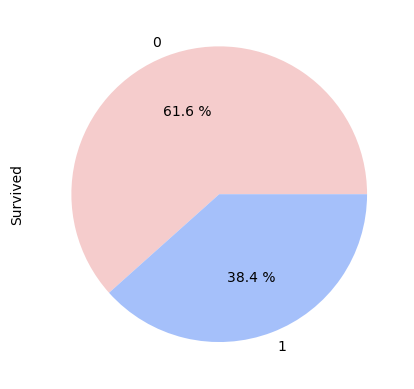

In [12]:
train_Survived=train_real.loc[:,"Survived"]
colores=["#f5cccc","#a5c0fa"]
train_Survived.value_counts().plot.pie(autopct="%0.1f %%", colors=colores)

In [14]:
Surv_100=train_real.query('Survived==1')

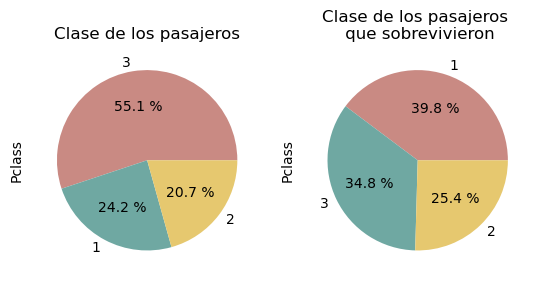

In [28]:
fig, axes = plt.subplots(1, 2)
train_Pclass=train_real.loc[:,"Pclass"]
colores=["#c98a83","#6fa8a2","#e6c86f"]
train_Pclass.value_counts().plot.pie(autopct="%0.1f %%", colors=colores, ax=axes[0], title='Clase de los pasajeros')
Surv_Pclass=Surv_100.loc[:,"Pclass"]
colores=["#c98a83","#6fa8a2","#e6c86f"]
Surv_Pclass.value_counts().plot.pie(autopct="%0.1f %%", colors=colores, ax=axes[1], title='Clase de los pasajeros \n que sobrevivieron')
plt.show()

<AxesSubplot:title={'center':'Sexo de los pasajeros \n que sobrevivieron'}, ylabel='Sex'>

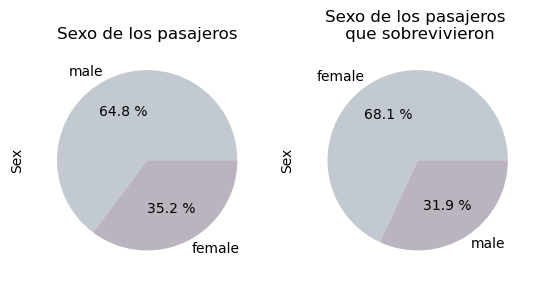

In [31]:
fig, axes = plt.subplots(1, 2)
train_Sex=train_real.loc[:,"Sex"]
colores=["#c3c9d0","#bbb3bd"]
train_Sex.value_counts().plot.pie(autopct="%0.1f %%", colors=colores, ax=axes[0], title='Sexo de los pasajeros')
Surv_Sex=Surv_100.loc[:,"Sex"]
colores=["#c3c9d0","#bbb3bd"]
Surv_Sex.value_counts().plot.pie(autopct="%0.1f %%", colors=colores, ax=axes[1], title='Sexo de los pasajeros \n que sobrevivieron')

<AxesSubplot:title={'center':'Embarcadero \n pasajeros que sobrevivieron'}, ylabel='Embarked'>

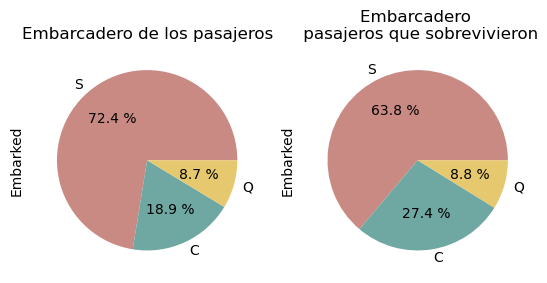

In [34]:
fig, axes = plt.subplots(1, 2)
train_Embarked=train_real.loc[:,"Embarked"]
colores=["#c98a83","#6fa8a2","#e6c86f"]
train_Embarked.value_counts().plot.pie(autopct="%0.1f %%", colors=colores, ax=axes[0], title='Embarcadero de los pasajeros')
Surv_Embarked=Surv_100.loc[:,"Embarked"]
colores=["#c98a83","#6fa8a2","#e6c86f"]
Surv_Embarked.value_counts().plot.pie(autopct="%0.1f %%", colors=colores, ax=axes[1], title='Embarcadero \n pasajeros que sobrevivieron')

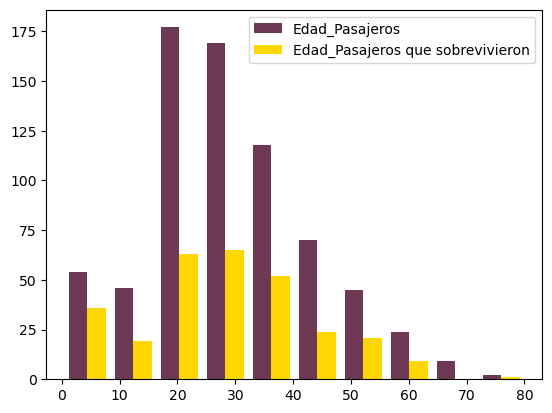

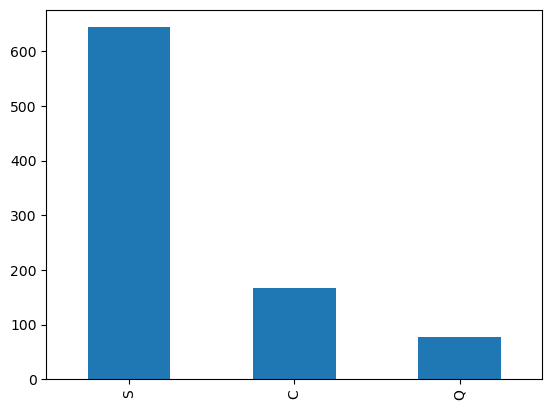

In [146]:
train_Age=train_real.loc[:,"Age"]
Surv_Age=Surv_100.loc[:,"Age"]
#Surv_Age.value_counts().plot.hist()
#train_Age.value_counts().plot.hist()
colores=['#6e3955','#ffd700']
plt.hist([train_Age,Surv_Age], label=['Edad_Pasajeros','Edad_Pasajeros que sobrevivieron'], color=colores)
plt.legend()
plt.show()

<AxesSubplot:>

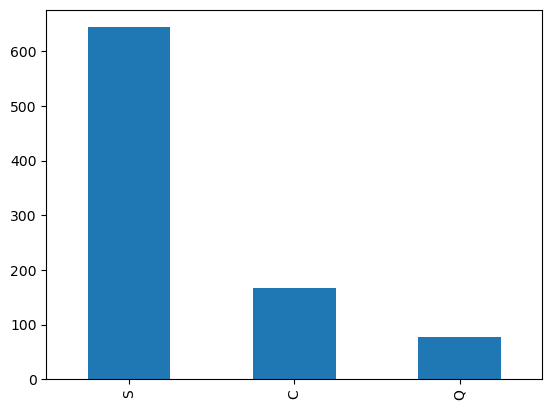

In [148]:
train_Embarked.value_counts().plot.bar()

<AxesSubplot:>

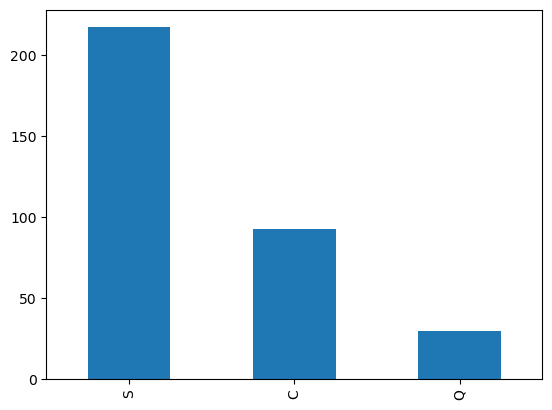

In [149]:
Surv_Embarked.value_counts().plot.bar()

In [70]:
copia_train_real=train_real.copy()

In [71]:
copia_train_real.pop('Parch')
copia_train_real.pop('Ticket')
copia_train_real.pop('Fare')
copia_train_real.pop('Cabin')
copia_train_real.pop('Embarked')
copia_train_real.pop('SibSp')

PassengerId
1      1
2      1
3      0
4      1
5      0
      ..
887    0
888    0
889    1
890    0
891    0
Name: SibSp, Length: 891, dtype: int64

In [74]:
copia_train_real.pop('Name')

PassengerId
1                                Braund, Mr. Owen Harris
2      Cumings, Mrs. John Bradley (Florence Briggs Th...
3                                 Heikkinen, Miss. Laina
4           Futrelle, Mrs. Jacques Heath (Lily May Peel)
5                               Allen, Mr. William Henry
                             ...                        
887                                Montvila, Rev. Juozas
888                         Graham, Miss. Margaret Edith
889             Johnston, Miss. Catherine Helen "Carrie"
890                                Behr, Mr. Karl Howell
891                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [75]:
copia_train_real


,Survived,Pclass,Sex,Age
PassengerId,,,,
1,0,3,male,22.0
2,1,1,female,38.0
3,1,3,female,26.0
4,1,1,female,35.0
5,0,3,male,35.0
...,...,...,...,...
887,0,2,male,27.0
888,1,1,female,19.0
889,0,3,female,NaN


In [118]:
 fig = px.scatter(copia_train_real, x="Age", y="Sex", color='Survived', symbol='Pclass') 

In [125]:
fig.show()
